# English Premier League Player Analysis  
## End-to-End Data Cleaning, EDA, Feature Engineering, Clustering, Classification, and Regression

This notebook provides a production-quality analysis pipeline for an English Premier League player dataset stored as `epl_player_stats.csv`.

It includes:
- Data loading and inspection
- Data cleaning and preprocessing
- Feature engineering
- Exploratory data analysis (EDA)
- Player segmentation with clustering
- Position prediction with classification
- Rating prediction with regression
- Visualizations and final insights

> Design note: the dataset may contain slightly different column names across exports. To make the notebook more robust, helper functions are included to detect likely columns for key football metrics (such as goals, assists, xG, xA, minutes, tackles, etc.).

## Notebook Workflow

1. Import required libraries and configure the environment  
2. Load the dataset and perform initial inspection  
3. Clean the data and fix structural issues  
4. Engineer football-relevant features  
5. Perform univariate, bivariate, and grouped EDA  
6. Segment players using KMeans clustering  
7. Predict player position using classification  
8. Predict player rating using regression  
9. Summarize insights, patterns, and limitations

In [1]:
# ==============================
# 1. Imports & Setup
# ==============================

import warnings
warnings.filterwarnings('ignore')

import re
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

## 2. Load Data

We load the CSV file `epl_player_stats.csv`, then inspect:
- The first few rows
- Dataset shape
- Data types and missingness
- Summary statistics

These checks help us understand the raw structure before making any transformations.

In [2]:
# ==============================
# 2. Load Data
# ==============================

DATA_PATH = Path('premier_league_complete_stats_until31thGameDayOnSeason2025-26.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Please place 'epl_player_stats.csv' in the same directory as this notebook."
    )

df = pd.read_csv(DATA_PATH, encoding='latin1')

print('Dataset loaded successfully.')
print(f'Shape: {df.shape}')
display(df.head())

print('\nDataFrame info:')
df.info()

display(df.describe(include='all').T)

Dataset loaded successfully.
Shape: (517, 99)


,player_name,team_name,position,accurateCrosses,accurateCrossesPercentage,accurateFinalThirdPasses,accurateLongBalls,accurateLongBallsPercentage,accurateOppositionHalfPasses,accurateOwnHalfPasses,accuratePasses,accuratePassesPercentage,aerialDuelsWon,aerialDuelsWonPercentage,aerialLost,appearances,assists,ballRecovery,bigChancesCreated,bigChancesMissed,blockedShots,cleanSheet,clearances,dispossessed,dribbledPast,duelLost,errorLeadToGoal,errorLeadToShot,expectedAssists,expectedGoals,fouls,freeKickGoal,goalConversionPercentage,goals,goalsAssistsSum,goalsConceded,goalsConcededInsideTheBox,goalsConcededOutsideTheBox,goalsFromInsideTheBox,goalsFromOutsideTheBox,goalsPrevented,groundDuelsWon,groundDuelsWonPercentage,headedGoals,highClaims,hitWoodwork,inaccuratePasses,interceptions,keyPasses,leftFootGoals,matchesStarted,minutesPlayed,offsides,ownGoals,passToAssist,penaltiesTaken,penaltyConceded,penaltyConversion,penaltyFaced,penaltyGoals,penaltySave,penaltyWon,possessionLost,possessionWonAttThird,punches,rating,redCards,rightFootGoals,savedShotsFromInsideTheBox,savedShotsFromOutsideTheBox,saves,savesCaught,savesParried,scoringFrequency,setPieceConversion,shotFromSetPiece,shotsFromInsideTheBox,shotsFromOutsideTheBox,shotsOffTarget,shotsOnTarget,successfulDribbles,successfulDribblesPercentage,tackles,tacklesWon,tacklesWonPercentage,totalAttemptAssist,totalContest,totalCross,totalDuelsWon,totalDuelsWonPercentage,totalLongBalls,totalOppositionHalfPasses,totalOwnHalfPasses,totalPasses,totalShots,totwAppearances,touches,wasFouled,yellowCards
0,Declan Rice,Arsenal,M,41,28.082,459,72,48.649,891,687,1578,87.813,44,72.131,17,30,5,154,14,3,10,10,65,15,12,77,1,0,6.073,2.873,20,0,11.111,4,9,21,15,6,3,1,NaN,77,56.204,1,0,0,219,30,59,0,29,2585,1,0,1,0,0,0.000,0,0,0,0,406,11,0,7.490,0,3,0,0,0,0,0,646.250,0.000,5,13,23,14,12,12,48.000,57,31,54.386,58,25,146,121,61.111,148,1054,743,1797,36,3,2327,8,2
1,Gabriel Magalhães,Arsenal,D,1,20.000,180,63,46.324,512,747,1259,88.724,87,66.923,43,25,4,46,5,3,6,13,149,2,4,62,1,2,1.734,1.880,14,0,16.667,3,7,15,10,5,3,0,NaN,60,75.949,1,0,1,160,18,6,2,24,2166,0,0,0,0,0,0.000,0,0,0,0,181,2,0,7.368,0,0,0,0,0,0,0,722.000,0.000,0,14,4,7,5,1,50.000,32,16,50.000,6,2,5,147,70.335,136,622,797,1419,18,5,1747,27,3
2,Bukayo Saka,Arsenal,F,36,32.432,300,14,36.842,419,105,524,76.720,22,44.898,27,27,3,105,9,8,22,7,10,29,15,140,0,1,5.762,6.994,28,0,9.524,6,9,16,11,5,6,0,NaN,136,54.618,1,0,1,159,14,54,3,22,2001,14,0,2,1,0,100.000,0,1,0,0,362,25,0,7.215,0,2,0,0,0,0,0,333.500,0.000,2,47,16,15,26,49,53.261,36,17,47.222,52,92,111,158,53.020,38,557,126,683,63,4,1236,51,1
3,Martín Zubimendi,Arsenal,M,2,18.182,369,48,49.485,833,661,1494,88.194,59,68.605,27,31,1,99,1,2,7,10,64,9,17,84,2,2,2.186,2.781,27,0,19.231,5,6,20,15,5,3,2,NaN,68,54.400,2,0,2,200,34,16,0,30,2604,0,0,0,0,0,0.000,0,0,0,0,258,6,0,7.087,0,3,0,0,0,0,0,520.800,0.000,0,19,7,10,9,6,50.000,54,30,55.556,16,12,11,127,60.190,97,985,709,1694,26,2,2026,10,4
4,Max Dowman,Arsenal,M,0,0.000,9,0,0.000,13,3,16,94.118,0,0.000,0,3,0,5,0,0,1,0,0,3,2,12,0,0,0.047,1.106,0,0,20.000,1,1,0,0,0,1,0,NaN,9,42.857,0,0,0,1,0,2,1,0,52,0,0,0,0,0,0.000,0,0,0,1,15,1,0,7.067,0,0,0,0,0,0,0,52.000,0.000,0,4,1,3,1,3,30.000,2,2,100.000,2,10,1,9,42.857,0,14,3,17,5,0,51,4,0



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 99 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   player_name                   517 non-null    object 
 1   team_name                     517 non-null    object 
 2   position                      517 non-null    object 
 3   accurateCrosses               517 non-null    int64  
 4   accurateCrossesPercentage     517 non-null    float64
 5   accurateFinalThirdPasses      517 non-null    int64  
 6   accurateLongBalls             517 non-null    int64  
 7   accurateLongBallsPercentage   517 non-null    float64
 8   accurateOppositionHalfPasses  517 non-null    int64  
 9   accurateOwnHalfPasses         517 non-null    int64  
 10  accuratePasses                517 non-null    int64  
 11  accuratePassesPercentage      517 non-null    float64
 12  aerialDuelsWon                517 non-null    i

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
player_name,517,517,Declan Rice,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team_name,517,20,Nottingham Forest,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
position,517,4,M,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accurateCrosses,517.000,NaN,NaN,NaN,5.019,8.229,0.000,0.000,1.000,7.000,53.000
accurateCrossesPercentage,517.000,NaN,NaN,NaN,16.213,17.319,0.000,0.000,15.385,26.667,100.000
accurateFinalThirdPasses,517.000,NaN,NaN,NaN,105.149,102.644,0.000,25.000,79.000,149.000,567.000
accurateLongBalls,517.000,NaN,NaN,NaN,24.988,35.832,0.000,3.000,12.000,32.000,301.000
accurateLongBallsPercentage,517.000,NaN,NaN,NaN,41.176,22.091,0.000,31.213,42.857,53.846,100.000
accurateOppositionHalfPasses,517.000,NaN,NaN,NaN,212.687,199.449,0.000,51.000,164.000,310.000,"1,000.000"
accurateOwnHalfPasses,517.000,NaN,NaN,NaN,218.822,238.988,0.000,38.000,141.000,331.000,"1,498.000"


## 3. Data Cleaning

A football dataset often contains:
- Mixed numeric/string columns
- Percentage values stored as strings (for example `'78%'`)
- Missing values for position-specific metrics (for example goalkeeping stats missing for outfield players)
- Duplicate player rows from repeated exports or merges

### Cleaning strategy
- Standardize column names for easier downstream processing
- Convert percentage-like fields to numeric proportions or percentages as floats
- Coerce numeric-looking text columns into numeric dtype
- Drop duplicates
- Keep missing values where they are structurally meaningful, then impute later only where models require it

> Why this approach?  
For sports data, missing values are often not purely random. A goalkeeper may legitimately have missing shooting metrics, and an outfield player may legitimately have missing goalkeeping metrics. Automatically replacing everything with zero too early can distort player profiles. We therefore clean first, preserve structure, and apply targeted imputations later.

In [3]:
# ==============================
# Helper Functions
# ==============================

def clean_column_name(col_name: str) -> str:
    """Standardize column names to snake_case for easier handling."""
    col_name = str(col_name).strip().lower()
    col_name = re.sub(r'[^a-z0-9]+', '_', col_name)
    col_name = re.sub(r'_+', '_', col_name).strip('_')
    return col_name


def normalize_text(value: str) -> str:
    """Normalize text for fuzzy column matching."""
    value = str(value).strip().lower()
    value = re.sub(r'[^a-z0-9]+', '', value)
    return value


def safe_divide(numerator, denominator):
    """Safely divide two arrays/series and return NaN when denominator is zero or missing."""
    numerator = pd.to_numeric(numerator, errors='coerce')
    denominator = pd.to_numeric(denominator, errors='coerce')
    return np.where((denominator.notna()) & (denominator != 0), numerator / denominator, np.nan)


def find_matching_column(df_: pd.DataFrame, candidate_terms, required_all=False):
    """
    Find the best matching column using normalized substring search.
    If required_all=True, all candidate terms must appear in the normalized name.
    Otherwise, any strong match is accepted.
    """
    normalized_map = {col: normalize_text(col) for col in df_.columns}
    normalized_terms = [normalize_text(term) for term in candidate_terms]

    matches = []
    for col, norm_col in normalized_map.items():
        if required_all:
            if all(term in norm_col for term in normalized_terms):
                matches.append(col)
        else:
            score = sum(term in norm_col for term in normalized_terms)
            if score > 0:
                matches.append((col, score, len(norm_col)))

    if required_all:
        return matches[0] if matches else None

    if matches:
        matches = sorted(matches, key=lambda x: (-x[1], x[2]))
        return matches[0][0]

    return None


def first_existing_column(df_: pd.DataFrame, candidate_groups):
    """Return the first column found from a list of candidate term groups."""
    for group in candidate_groups:
        col = find_matching_column(df_, group)
        if col is not None:
            return col
    return None


def get_numeric_columns(df_: pd.DataFrame, min_non_null_ratio=0.30):
    """Return numeric columns with sufficient data coverage."""
    numeric_cols = df_.select_dtypes(include=[np.number]).columns.tolist()
    valid_cols = [
        col for col in numeric_cols
        if df_[col].notna().mean() >= min_non_null_ratio and df_[col].nunique(dropna=True) > 1
    ]
    return valid_cols

In [4]:
# ==============================
# 3. Data Cleaning
# ==============================

# Work on a copy to preserve the raw import if needed for debugging or comparison.
df_clean = df.copy()

# Standardize column names.
df_clean.columns = [clean_column_name(col) for col in df_clean.columns]

# Remove duplicated rows if present.
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Convert percentage strings such as '78%' into floats.
# We preserve the same percentage scale (78.0 rather than 0.78) to remain intuitive for EDA.
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        sample_values = df_clean[col].dropna().astype(str).head(20)
        if len(sample_values) > 0 and sample_values.str.contains('%').mean() >= 0.5:
            df_clean[col] = (
                df_clean[col]
                .astype(str)
                .str.replace('%', '', regex=False)
                .str.replace(',', '', regex=False)
            )
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Attempt numeric coercion for object columns where most values look numeric.
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        cleaned_series = (
            df_clean[col]
            .astype(str)
            .str.strip()
            .str.replace(',', '', regex=False)
        )
        numeric_candidate = pd.to_numeric(cleaned_series, errors='coerce')
        non_null_mask = df_clean[col].notna()
        if non_null_mask.sum() > 0:
            conversion_ratio = numeric_candidate[non_null_mask].notna().mean()
            if conversion_ratio >= 0.80:
                df_clean[col] = numeric_candidate

print(f'Duplicates removed: {duplicates_before}')
print(f'Cleaned shape: {df_clean.shape}')
display(df_clean.head())

missing_summary = (
    df_clean.isna()
    .mean()
    .sort_values(ascending=False)
    .rename('missing_ratio')
    .to_frame()
)

display(missing_summary.head(20))

Duplicates removed: 0
Cleaned shape: (517, 99)


,player_name,team_name,position,accuratecrosses,accuratecrossespercentage,accuratefinalthirdpasses,accuratelongballs,accuratelongballspercentage,accurateoppositionhalfpasses,accurateownhalfpasses,accuratepasses,accuratepassespercentage,aerialduelswon,aerialduelswonpercentage,aeriallost,appearances,assists,ballrecovery,bigchancescreated,bigchancesmissed,blockedshots,cleansheet,clearances,dispossessed,dribbledpast,duellost,errorleadtogoal,errorleadtoshot,expectedassists,expectedgoals,fouls,freekickgoal,goalconversionpercentage,goals,goalsassistssum,goalsconceded,goalsconcededinsidethebox,goalsconcededoutsidethebox,goalsfrominsidethebox,goalsfromoutsidethebox,goalsprevented,groundduelswon,groundduelswonpercentage,headedgoals,highclaims,hitwoodwork,inaccuratepasses,interceptions,keypasses,leftfootgoals,matchesstarted,minutesplayed,offsides,owngoals,passtoassist,penaltiestaken,penaltyconceded,penaltyconversion,penaltyfaced,penaltygoals,penaltysave,penaltywon,possessionlost,possessionwonattthird,punches,rating,redcards,rightfootgoals,savedshotsfrominsidethebox,savedshotsfromoutsidethebox,saves,savescaught,savesparried,scoringfrequency,setpiececonversion,shotfromsetpiece,shotsfrominsidethebox,shotsfromoutsidethebox,shotsofftarget,shotsontarget,successfuldribbles,successfuldribblespercentage,tackles,tackleswon,tackleswonpercentage,totalattemptassist,totalcontest,totalcross,totalduelswon,totalduelswonpercentage,totallongballs,totaloppositionhalfpasses,totalownhalfpasses,totalpasses,totalshots,totwappearances,touches,wasfouled,yellowcards
0,Declan Rice,Arsenal,M,41,28.082,459,72,48.649,891,687,1578,87.813,44,72.131,17,30,5,154,14,3,10,10,65,15,12,77,1,0,6.073,2.873,20,0,11.111,4,9,21,15,6,3,1,NaN,77,56.204,1,0,0,219,30,59,0,29,2585,1,0,1,0,0,0.000,0,0,0,0,406,11,0,7.490,0,3,0,0,0,0,0,646.250,0.000,5,13,23,14,12,12,48.000,57,31,54.386,58,25,146,121,61.111,148,1054,743,1797,36,3,2327,8,2
1,Gabriel Magalhães,Arsenal,D,1,20.000,180,63,46.324,512,747,1259,88.724,87,66.923,43,25,4,46,5,3,6,13,149,2,4,62,1,2,1.734,1.880,14,0,16.667,3,7,15,10,5,3,0,NaN,60,75.949,1,0,1,160,18,6,2,24,2166,0,0,0,0,0,0.000,0,0,0,0,181,2,0,7.368,0,0,0,0,0,0,0,722.000,0.000,0,14,4,7,5,1,50.000,32,16,50.000,6,2,5,147,70.335,136,622,797,1419,18,5,1747,27,3
2,Bukayo Saka,Arsenal,F,36,32.432,300,14,36.842,419,105,524,76.720,22,44.898,27,27,3,105,9,8,22,7,10,29,15,140,0,1,5.762,6.994,28,0,9.524,6,9,16,11,5,6,0,NaN,136,54.618,1,0,1,159,14,54,3,22,2001,14,0,2,1,0,100.000,0,1,0,0,362,25,0,7.215,0,2,0,0,0,0,0,333.500,0.000,2,47,16,15,26,49,53.261,36,17,47.222,52,92,111,158,53.020,38,557,126,683,63,4,1236,51,1
3,Martín Zubimendi,Arsenal,M,2,18.182,369,48,49.485,833,661,1494,88.194,59,68.605,27,31,1,99,1,2,7,10,64,9,17,84,2,2,2.186,2.781,27,0,19.231,5,6,20,15,5,3,2,NaN,68,54.400,2,0,2,200,34,16,0,30,2604,0,0,0,0,0,0.000,0,0,0,0,258,6,0,7.087,0,3,0,0,0,0,0,520.800,0.000,0,19,7,10,9,6,50.000,54,30,55.556,16,12,11,127,60.190,97,985,709,1694,26,2,2026,10,4
4,Max Dowman,Arsenal,M,0,0.000,9,0,0.000,13,3,16,94.118,0,0.000,0,3,0,5,0,0,1,0,0,3,2,12,0,0,0.047,1.106,0,0,20.000,1,1,0,0,0,1,0,NaN,9,42.857,0,0,0,1,0,2,1,0,52,0,0,0,0,0,0.000,0,0,0,1,15,1,0,7.067,0,0,0,0,0,0,0,52.000,0.000,0,4,1,3,1,3,30.000,2,2,100.000,2,10,1,9,42.857,0,14,3,17,5,0,51,4,0


,missing_ratio
goalsprevented,0.934
expectedgoals,0.166
expectedassists,0.008
position,0.000
team_name,0.000
accuratecrosses,0.000
accuratecrossespercentage,0.000
accuratelongballspercentage,0.000
accurateoppositionhalfpasses,0.000
accuratefinalthirdpasses,0.000


## 4. Feature Engineering

We create domain-relevant features to better compare players across different playing time and roles.

### Features to create
- `goals_per90`
- `assists_per90`
- `xg_per90`
- `tackles_per90`
- `goal_efficiency = goals / expected_goals`
- `assist_efficiency = assists / expected_assists`
- `total_contribution = goals + assists`
- `defensive_score = tackles + interceptions + clearances`

> Why per-90 metrics?  
Raw totals can be misleading because players have very different minutes played. Per-90 metrics normalize production and make comparisons fairer.

> Why efficiency metrics?  
Comparing actual output to expected output helps identify over-performance, under-performance, and potential regression candidates.

In [5]:
# ==============================
# 4. Feature Engineering
# ==============================

column_map = {
    'player_name': first_existing_column(df_clean, [['player_name'], ['player', 'name'], ['name']]),
    'team_name': first_existing_column(df_clean, [['team_name'], ['team'], ['squad']]),
    'position': first_existing_column(df_clean, [['position'], ['pos']]),
    'minutes': first_existing_column(df_clean, [['minutes_played'], ['minutes'], ['mins']]),
    'goals': first_existing_column(df_clean, [['goals'], ['goal']]),
    'assists': first_existing_column(df_clean, [['assists'], ['assist']]),
    'expected_goals': first_existing_column(df_clean, [['expected_goals'], ['xg']]),
    'expected_assists': first_existing_column(df_clean, [['expected_assists'], ['xa']]),
    'tackles': first_existing_column(df_clean, [['tackles'], ['tkl']]),
    'interceptions': first_existing_column(df_clean, [['interceptions'], ['interception'], ['int']]),
    'clearances': first_existing_column(df_clean, [['clearances'], ['clearance'], ['clr']]),
    'key_passes': first_existing_column(df_clean, [['key_passes'], ['keypasses'], ['key', 'passes']]),
    'rating': first_existing_column(df_clean, [['rating'], ['match_rating'], ['average_rating']])
}

print('Detected core columns:')
display(pd.Series(column_map, name='matched_column').to_frame())

analysis_df = df_clean.copy()

for logical_name, col in column_map.items():
    if col is not None and logical_name not in {'player_name', 'team_name', 'position'}:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

minutes_col = column_map['minutes']
goals_col = column_map['goals']
assists_col = column_map['assists']
xg_col = column_map['expected_goals']
xa_col = column_map['expected_assists']
tackles_col = column_map['tackles']
interceptions_col = column_map['interceptions']
clearances_col = column_map['clearances']

if minutes_col is None:
    raise ValueError('A minutes-played column could not be identified. Per-90 features require minutes data.')

minutes_per_90 = analysis_df[minutes_col] / 90.0

analysis_df['goals_per90'] = safe_divide(analysis_df[goals_col], minutes_per_90) if goals_col else np.nan
analysis_df['assists_per90'] = safe_divide(analysis_df[assists_col], minutes_per_90) if assists_col else np.nan
analysis_df['xg_per90'] = safe_divide(analysis_df[xg_col], minutes_per_90) if xg_col else np.nan
analysis_df['tackles_per90'] = safe_divide(analysis_df[tackles_col], minutes_per_90) if tackles_col else np.nan

analysis_df['goal_efficiency'] = safe_divide(analysis_df[goals_col], analysis_df[xg_col]) if goals_col and xg_col else np.nan
analysis_df['assist_efficiency'] = safe_divide(analysis_df[assists_col], analysis_df[xa_col]) if assists_col and xa_col else np.nan

analysis_df['total_contribution'] = 0
if goals_col:
    analysis_df['total_contribution'] += analysis_df[goals_col].fillna(0)
if assists_col:
    analysis_df['total_contribution'] += analysis_df[assists_col].fillna(0)

analysis_df['defensive_score'] = 0
for defensive_col in [tackles_col, interceptions_col, clearances_col]:
    if defensive_col:
        analysis_df['defensive_score'] += analysis_df[defensive_col].fillna(0)

engineered_features = [
    'goals_per90',
    'assists_per90',
    'xg_per90',
    'tackles_per90',
    'goal_efficiency',
    'assist_efficiency',
    'total_contribution',
    'defensive_score'
]

display(analysis_df[engineered_features].describe().T)

Detected core columns:


,matched_column
player_name,player_name
team_name,team_name
position,position
minutes,minutesplayed
goals,goals
assists,assists
expected_goals,expectedgoals
expected_assists,expectedassists
tackles,tackles
interceptions,interceptions


,count,mean,std,min,25%,50%,75%,max
goals_per90,517.000,0.120,0.316,0.000,0.000,0.000,0.152,6.000
assists_per90,517.000,0.085,0.272,0.000,0.000,0.000,0.121,5.625
xg_per90,431.000,0.157,0.181,0.001,0.047,0.098,0.203,1.915
tackles_per90,517.000,1.540,1.356,0.000,0.696,1.427,2.117,16.364
goal_efficiency,431.000,0.760,0.886,0.000,0.000,0.662,1.181,7.943
assist_efficiency,513.000,186.745,"4,204.817",0.000,0.000,0.000,1.381,"95,238.095"
total_contribution,517.000,2.634,3.626,0.000,0.000,1.000,4.000,29.000
defensive_score,517.000,62.853,62.529,0.000,15.000,41.000,92.000,317.000


## 5. Exploratory Data Analysis (EDA)

This section explores player performance from multiple perspectives.

### Univariate analysis
We inspect the distributions of:
- Goals
- Assists
- Expected goals (xG)

### Bivariate analysis
We explore relationships between:
- xG and goals
- Assists and key passes
- Numeric feature correlations

### Grouped analysis
We compare aggregates:
- By position
- By team

The goal is to reveal scoring trends, creative influence, defensive profiles, and team-level differences.

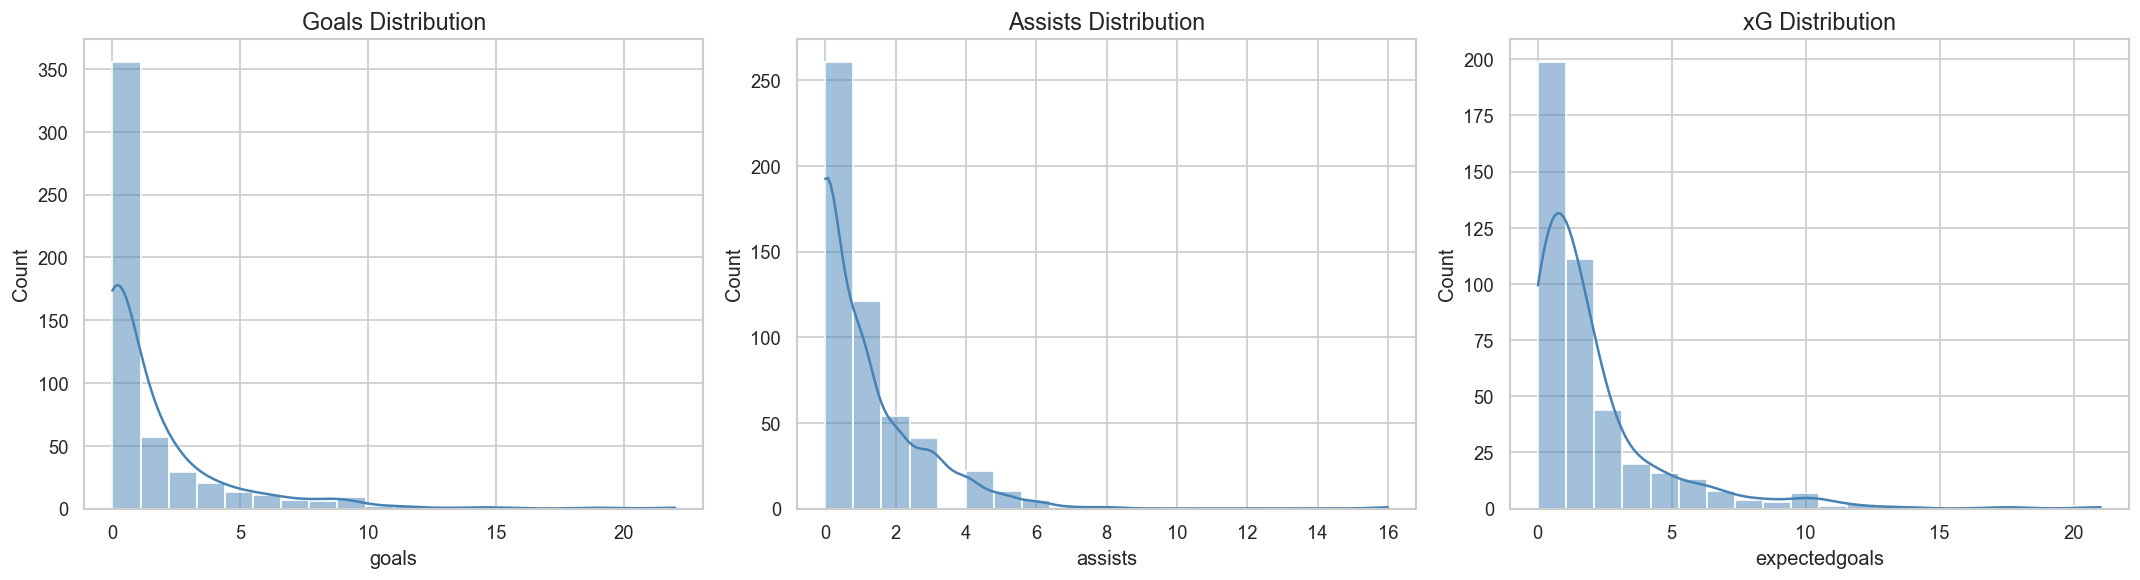

In [6]:
# ==============================
# 5A. Univariate Analysis
# ==============================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

univariate_targets = [
    ('Goals Distribution', column_map['goals']),
    ('Assists Distribution', column_map['assists']),
    ('xG Distribution', column_map['expected_goals'])
]

for ax, (title, col) in zip(axes, univariate_targets):
    if col is not None:
        sns.histplot(analysis_df[col].dropna(), kde=True, bins=20, ax=ax, color='steelblue')
        ax.set_title(title)
        ax.set_xlabel(col)
    else:
        ax.text(0.5, 0.5, f'Column not found for\n{title}', ha='center', va='center')
        ax.set_axis_off()

plt.tight_layout()
plt.show()

### Interpretation Guide: Univariate Distributions

When you run the plots above, look for:
- Right-skewed goal and assist distributions, which are common because only a small subset of players produce elite attacking output
- Whether xG is more smoothly distributed than goals, since expected metrics typically reduce random finishing variance
- Potential outliers that may represent elite forwards, set-piece specialists, or unusually small-sample performers

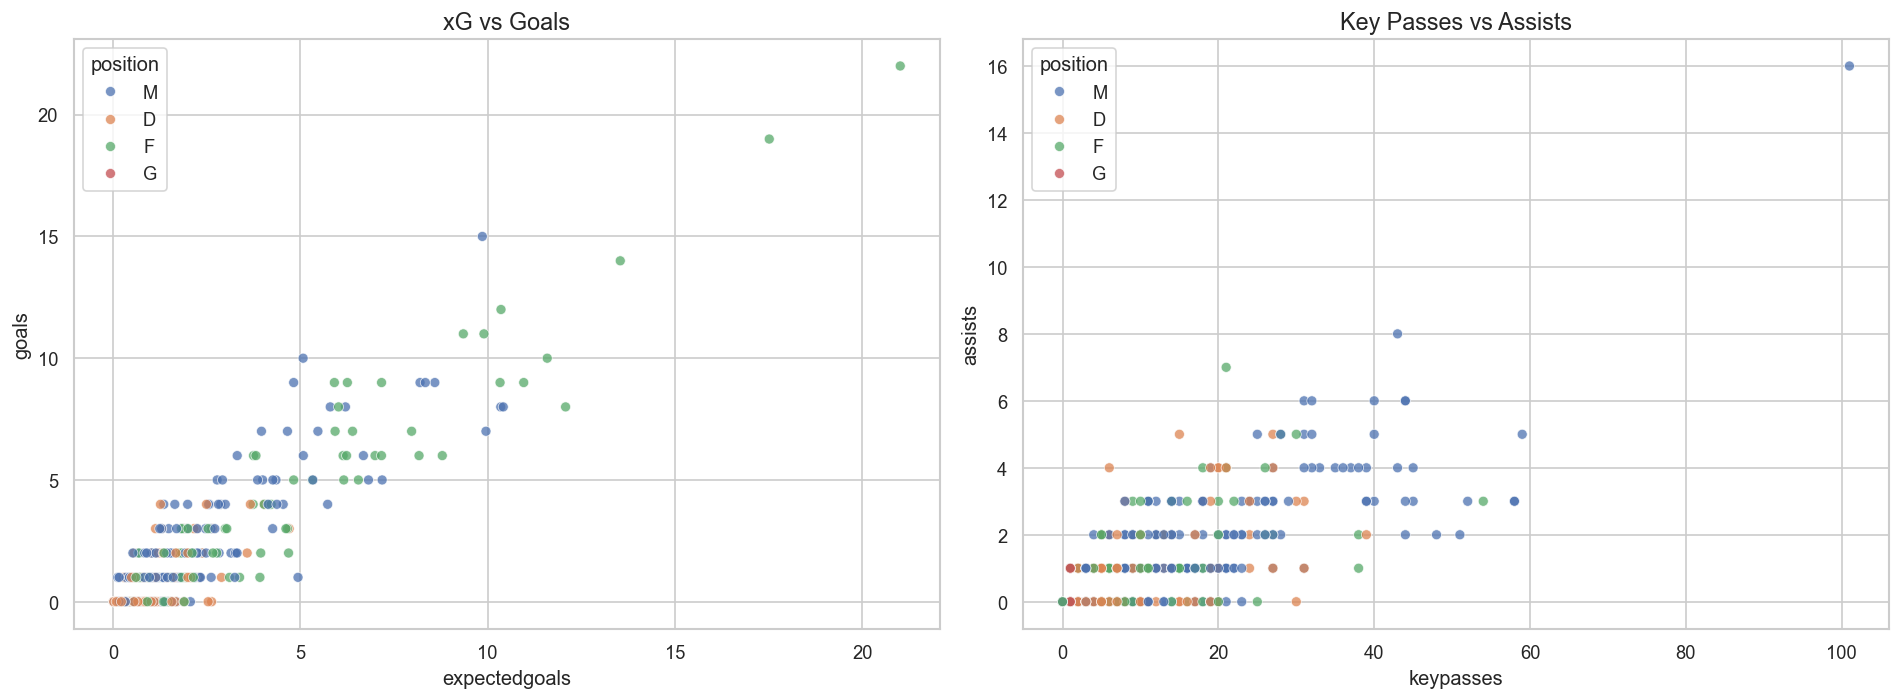

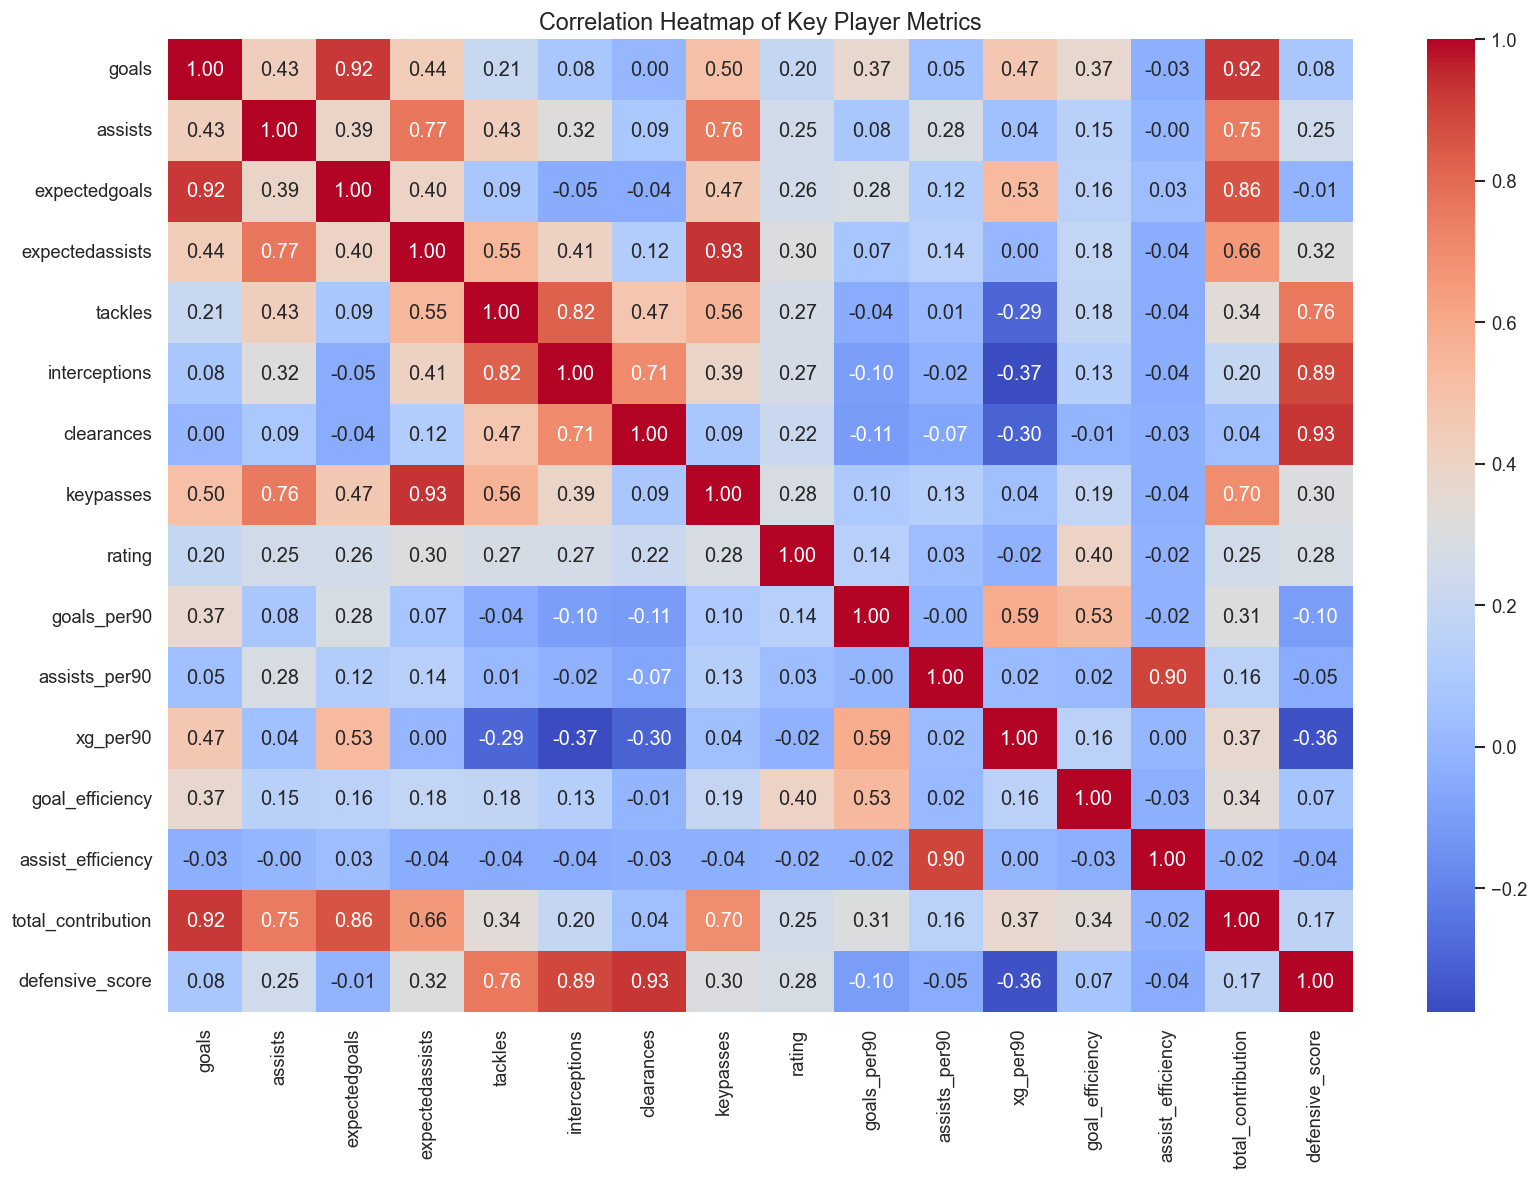

In [7]:
# ==============================
# 5B. Bivariate Analysis
# ==============================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if column_map['expected_goals'] is not None and column_map['goals'] is not None:
    sns.scatterplot(
        data=analysis_df,
        x=column_map['expected_goals'],
        y=column_map['goals'],
        hue=column_map['position'] if column_map['position'] else None,
        alpha=0.75,
        ax=axes[0]
    )
    axes[0].set_title('xG vs Goals')
else:
    axes[0].text(0.5, 0.5, 'xG or Goals column not found', ha='center', va='center')
    axes[0].set_axis_off()

if column_map['assists'] is not None and column_map['key_passes'] is not None:
    sns.scatterplot(
        data=analysis_df,
        x=column_map['key_passes'],
        y=column_map['assists'],
        hue=column_map['position'] if column_map['position'] else None,
        alpha=0.75,
        ax=axes[1]
    )
    axes[1].set_title('Key Passes vs Assists')
else:
    axes[1].text(0.5, 0.5, 'Assists or Key Passes column not found', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

priority_cols = [
    c for c in [
        column_map['goals'],
        column_map['assists'],
        column_map['expected_goals'],
        column_map['expected_assists'],
        column_map['tackles'],
        column_map['interceptions'],
        column_map['clearances'],
        column_map['key_passes'],
        column_map['rating'],
        'goals_per90',
        'assists_per90',
        'xg_per90',
        'goal_efficiency',
        'assist_efficiency',
        'total_contribution',
        'defensive_score'
    ] if c is not None and c in analysis_df.columns
]

corr_df = analysis_df[priority_cols].select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f', square=False)
plt.title('Correlation Heatmap of Key Player Metrics')
plt.tight_layout()
plt.show()

### Interpretation Guide: Relationships and Correlations

Useful questions to answer from these plots:
- Do goals increase roughly in line with xG, or are there players who finish far above or below expectation?
- Do players with many key passes consistently generate assists, or does finishing variance weaken that relationship?
- Which features correlate most strongly with rating?  
- Are attacking and defensive metrics negatively related, suggesting clearer positional specialization?

,goals,assists,expectedgoals,expectedassists,tackles,interceptions,clearances,goals_per90,assists_per90,xg_per90,total_contribution,defensive_score
position,,,,,,,,,,,,
D,0.581,0.744,0.913,0.806,24.192,14.919,65.488,0.036,0.044,0.060,1.326,104.599
F,3.495,1.031,3.989,0.960,10.361,3.278,12.278,0.271,0.090,0.327,4.526,25.918
G,0.000,0.057,0.162,0.050,0.571,0.257,22.200,0.000,0.002,0.007,0.057,23.029
M,1.746,1.507,1.927,1.503,24.282,10.432,17.793,0.140,0.130,0.153,3.254,52.507


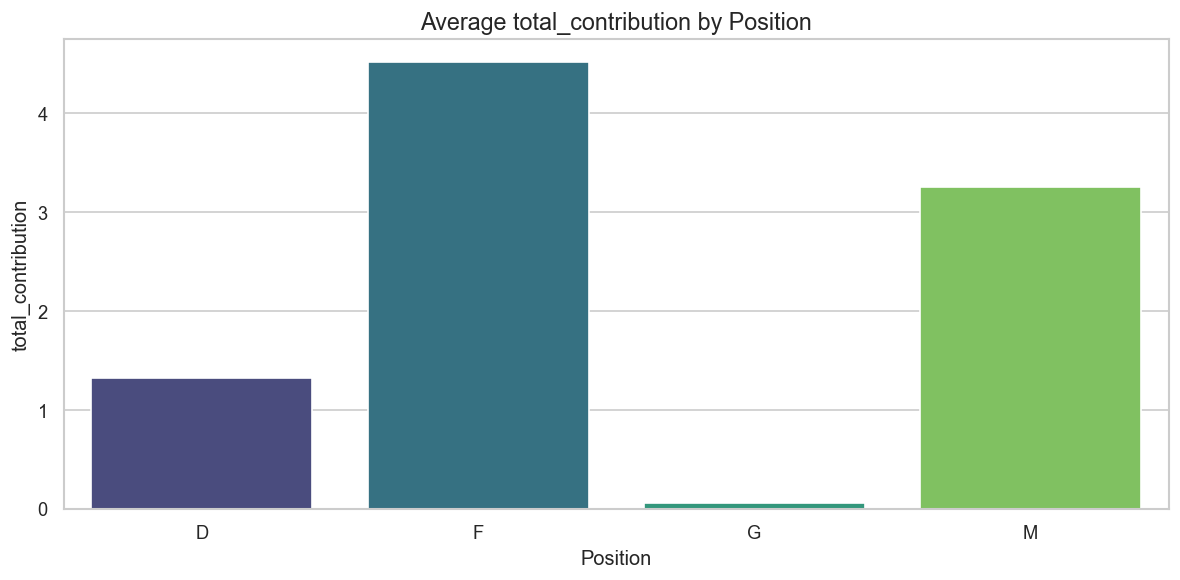

,avg_total_contribution
team_name,
Manchester City,4.577
Arsenal,4.167
Liverpool,3.636
Chelsea,3.625
Manchester United,3.370
Brentford,3.217
Everton,2.864
Fulham,2.826
Newcastle United,2.760


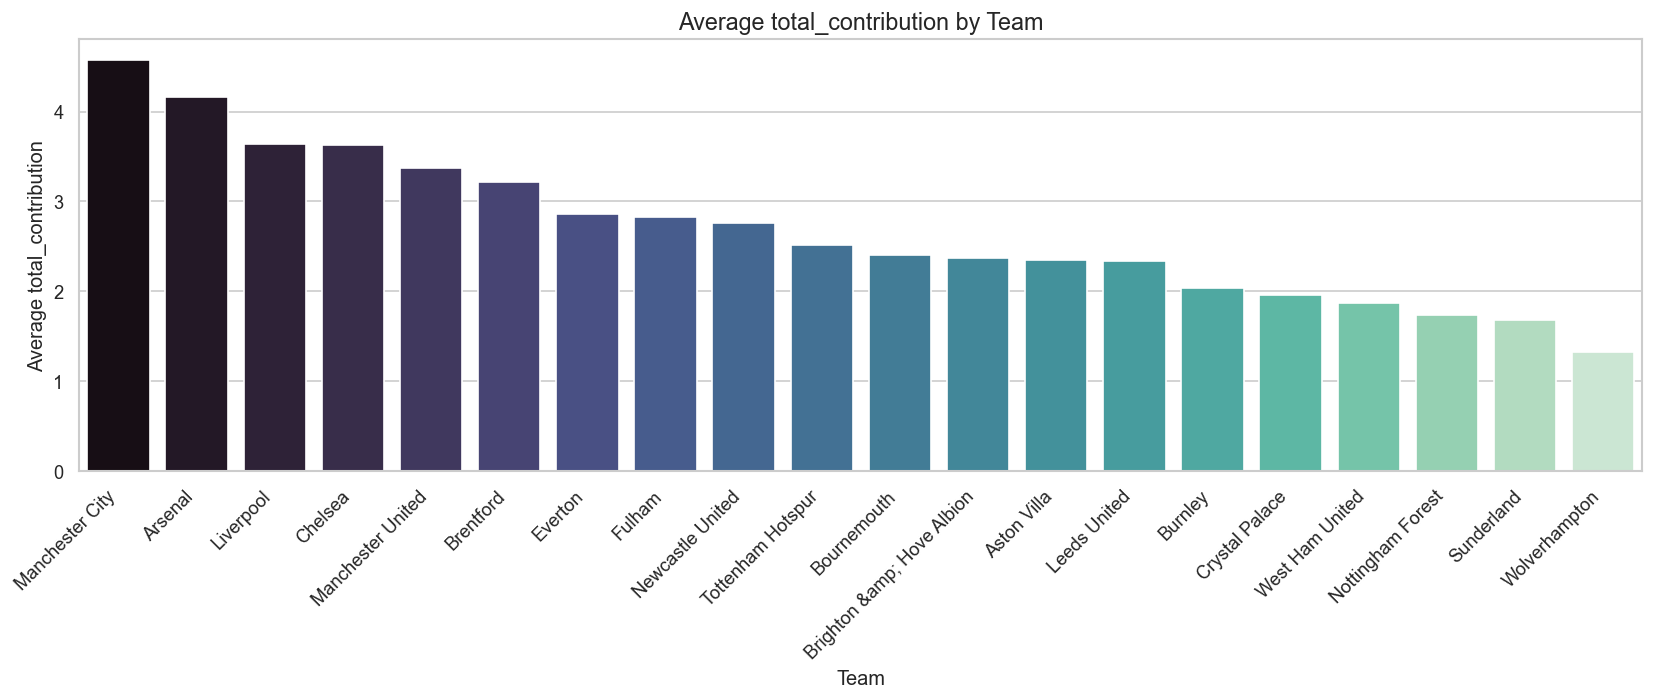

In [8]:
# ==============================
# 5C. Grouped Analysis
# ==============================

position_col = column_map['position']
team_col = column_map['team_name']
player_col = column_map['player_name']
rating_col = column_map['rating']

group_metrics = [
    c for c in [
        column_map['goals'],
        column_map['assists'],
        column_map['expected_goals'],
        column_map['expected_assists'],
        column_map['tackles'],
        column_map['interceptions'],
        column_map['clearances'],
        'goals_per90',
        'assists_per90',
        'xg_per90',
        'total_contribution',
        'defensive_score'
    ] if c is not None and c in analysis_df.columns
]

if position_col is not None:
    position_summary = analysis_df.groupby(position_col)[group_metrics].mean(numeric_only=True).sort_index()
    display(position_summary)

    plot_metric = 'total_contribution' if 'total_contribution' in analysis_df.columns else group_metrics[0]
    plt.figure(figsize=(10, 5))
    sns.barplot(x=position_summary.index, y=position_summary[plot_metric].values, palette='viridis')
    plt.title(f'Average {plot_metric} by Position')
    plt.xlabel('Position')
    plt.ylabel(plot_metric)
    plt.tight_layout()
    plt.show()

if team_col is not None:
    team_metric = 'total_contribution' if 'total_contribution' in analysis_df.columns else group_metrics[0]
    team_summary = (
        analysis_df.groupby(team_col)[team_metric]
        .mean()
        .sort_values(ascending=False)
    )
    display(team_summary.to_frame(name=f'avg_{team_metric}'))

    plt.figure(figsize=(14, 6))
    sns.barplot(x=team_summary.index, y=team_summary.values, palette='mako')
    plt.title(f'Average {team_metric} by Team')
    plt.xlabel('Team')
    plt.ylabel(f'Average {team_metric}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Interpretation Guide: Grouped Analysis

Focus on:
- Which positions dominate attacking output and which dominate defensive output
- Whether teams with stronger average attacking contribution also show stronger ratings
- Whether player roles appear cleanly separated or whether modern hybrid roles blur traditional positional boundaries

## 6. Machine Learning

This section includes three modeling tasks:

### A. Clustering
Use KMeans to segment players into performance/style groups.

### B. Classification
Predict player position using player statistics.

### C. Regression
Predict player rating using available metrics.

> Modeling note:  
Only numeric features are used for most models. Missing values are imputed inside pipelines, and scaling is applied where distance-based methods require it.

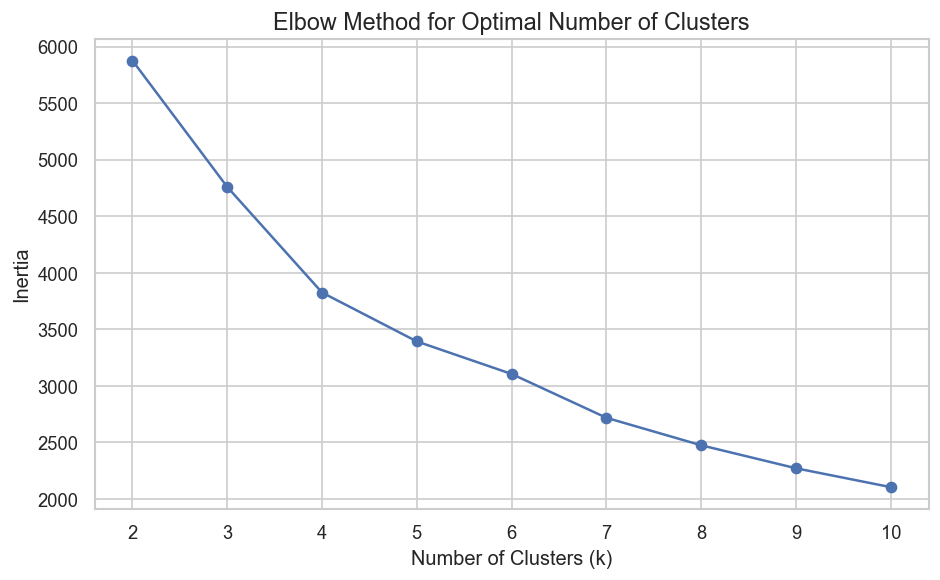

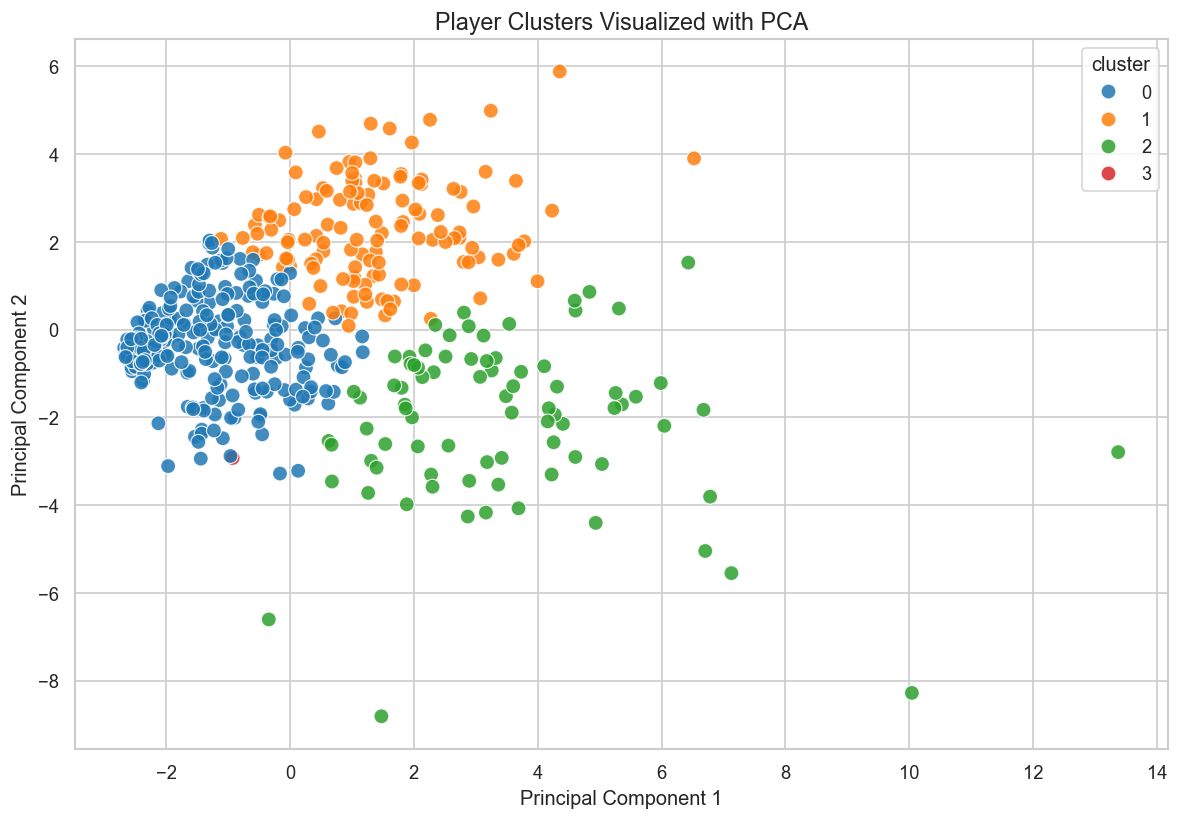

,goals,assists,expectedgoals,expectedassists,tackles,interceptions,clearances,keypasses,goals_per90,assists_per90,xg_per90,goal_efficiency,assist_efficiency,total_contribution,defensive_score
cluster,,,,,,,,,,,,,,,
0,0.513,0.412,0.961,0.450,9.110,3.961,15.594,4.831,0.075,0.058,0.150,0.526,1.076,0.925,28.666
1,1.220,1.512,1.367,1.476,42.961,24.661,82.748,14.425,0.056,0.072,0.062,0.915,1.115,2.732,150.370
2,6.148,2.852,5.885,2.773,25.864,9.420,21.099,28.160,0.394,0.143,0.323,1.166,1.154,9.000,56.383
3,0.000,1.000,NaN,0.000,1.000,0.000,1.000,1.000,0.000,5.625,NaN,NaN,"95,238.095",1.000,2.000


In [9]:
# ==============================
# 6A. Clustering (Unsupervised)
# ==============================

preferred_cluster_features = [
    column_map['goals'],
    column_map['assists'],
    column_map['expected_goals'],
    column_map['expected_assists'],
    column_map['tackles'],
    column_map['interceptions'],
    column_map['clearances'],
    column_map['key_passes'],
    'goals_per90',
    'assists_per90',
    'xg_per90',
    'goal_efficiency',
    'assist_efficiency',
    'total_contribution',
    'defensive_score'
]

cluster_features = [
    col for col in preferred_cluster_features
    if col is not None and col in analysis_df.columns and pd.api.types.is_numeric_dtype(analysis_df[col])
]

cluster_df = analysis_df[cluster_features].copy()

cluster_imputer = SimpleImputer(strategy='median')
cluster_scaler = StandardScaler()

X_cluster = cluster_imputer.fit_transform(cluster_df)
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

inertia_values = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia_values, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
analysis_df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_pca = pca.fit_transform(X_cluster_scaled)

pca_df = pd.DataFrame(cluster_pca, columns=['pc1', 'pc2'])
pca_df['cluster'] = analysis_df['cluster']
if player_col is not None:
    pca_df['player_name'] = analysis_df[player_col]
if position_col is not None:
    pca_df['position'] = analysis_df[position_col]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='pc1', y='pc2', hue='cluster', palette='tab10', s=80, alpha=0.85)
plt.title('Player Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

cluster_profile = analysis_df.groupby('cluster')[cluster_features].mean(numeric_only=True)
display(cluster_profile)

### Interpreting Clusters

After running clustering, inspect the cluster means and PCA spread to label groups such as:
- High-output attackers
- Creative midfielders
- Defensive specialists
- Low-minute or low-involvement players

Cluster interpretation is most meaningful when numerical profiles are combined with football context rather than treated as purely statistical buckets.

Classification Accuracy: 0.7885


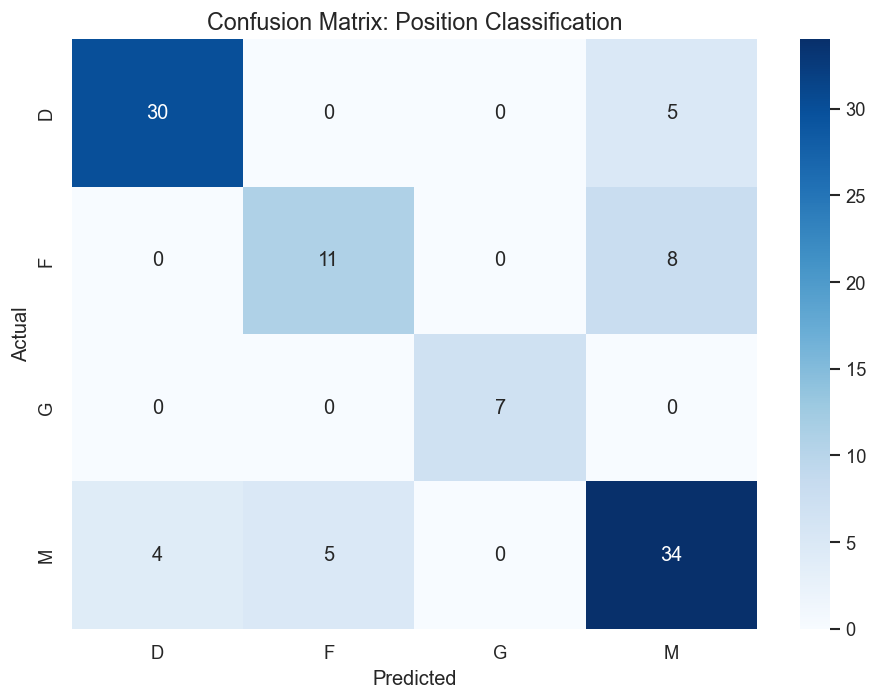

Classification Report:
              precision    recall  f1-score   support

           D       0.88      0.86      0.87        35
           F       0.69      0.58      0.63        19
           G       1.00      1.00      1.00         7
           M       0.72      0.79      0.76        43

    accuracy                           0.79       104
   macro avg       0.82      0.81      0.81       104
weighted avg       0.79      0.79      0.79       104



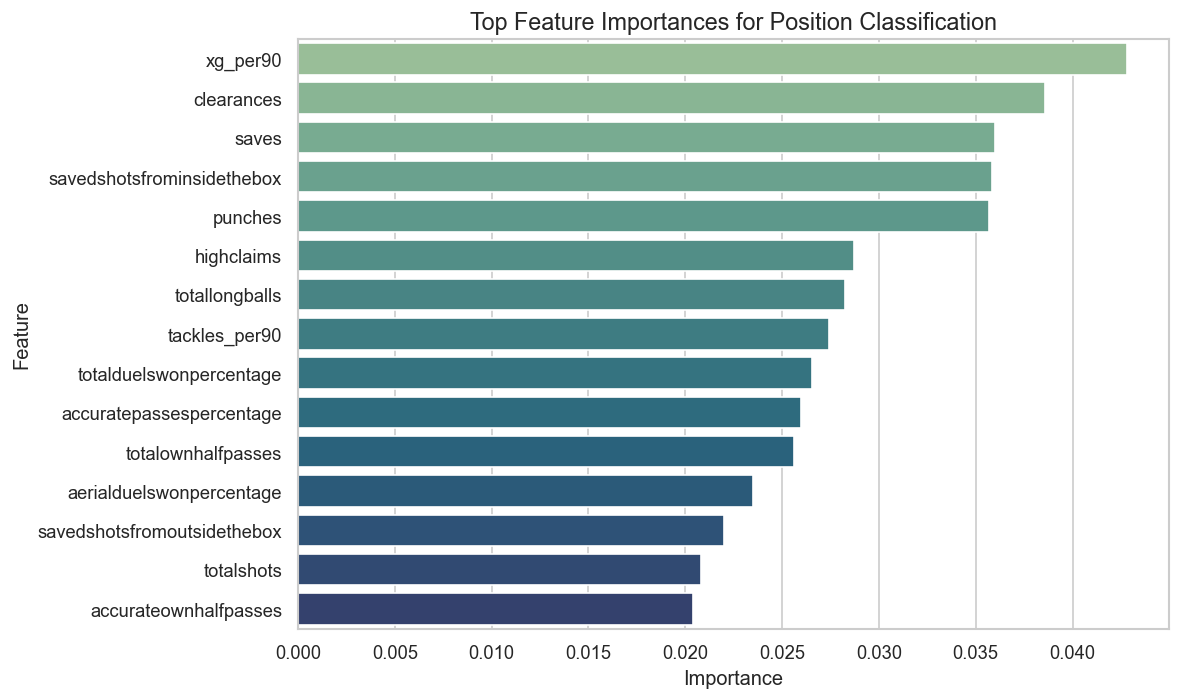

In [10]:
# ==============================
# 6B. Classification: Predict Position
# ==============================

if position_col is None:
    raise ValueError('Position column could not be identified. Classification task requires a target position column.')

classification_features = get_numeric_columns(analysis_df)
classification_features = [
    col for col in classification_features
    if col not in ['cluster']
]

X_cls = analysis_df[classification_features].copy()
y_cls = analysis_df[position_col].astype(str).fillna('Unknown')

label_encoder = LabelEncoder()
y_cls_encoded = label_encoder.fit_transform(y_cls)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_cls_encoded
)

clf_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

clf_pipeline.fit(X_train_cls, y_train_cls)
y_pred_cls = clf_pipeline.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, y_pred_cls)
print(f'Classification Accuracy: {accuracy:.4f}')

cm = confusion_matrix(y_test_cls, y_pred_cls)
cm_labels = label_encoder.inverse_transform(np.unique(y_cls_encoded))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels)
plt.title('Confusion Matrix: Position Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_test_cls, y_pred_cls, target_names=label_encoder.classes_))

clf_model = clf_pipeline.named_steps['model']
feature_importance_cls = (
    pd.Series(clf_model.feature_importances_, index=classification_features)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_cls.values, y=feature_importance_cls.index, palette='crest')
plt.title('Top Feature Importances for Position Classification')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Classification Interpretation

A strong classifier suggests that the statistical profiles of positions are distinct.  
If the model confuses midfielders and forwards, or defenders and defensive midfielders, that is not necessarily a failure. It may reflect real tactical overlap in modern football roles.

RMSE: 0.4020
R^2 Score: 0.6873


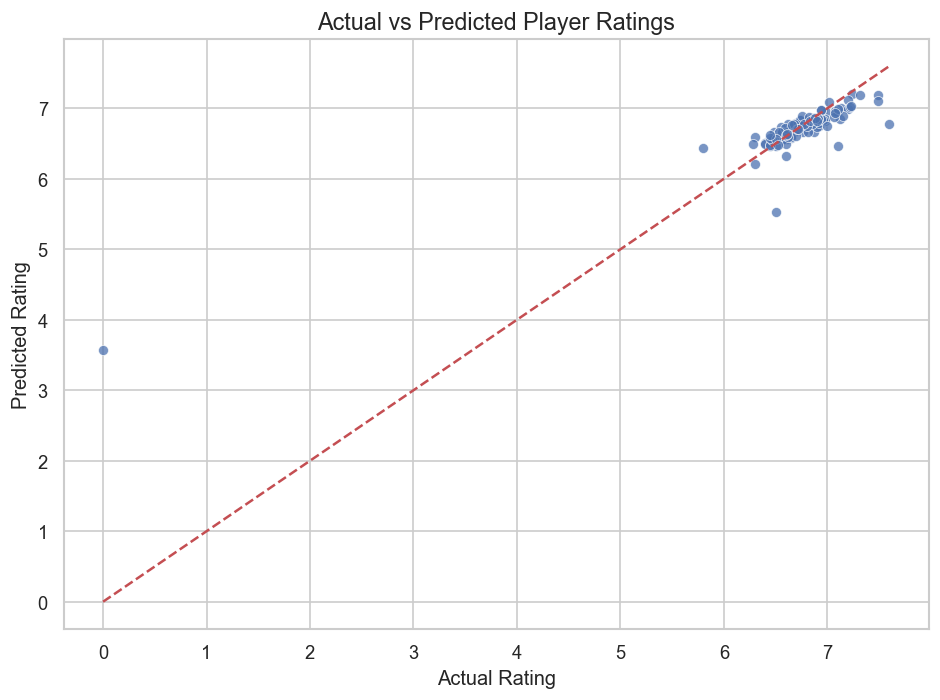

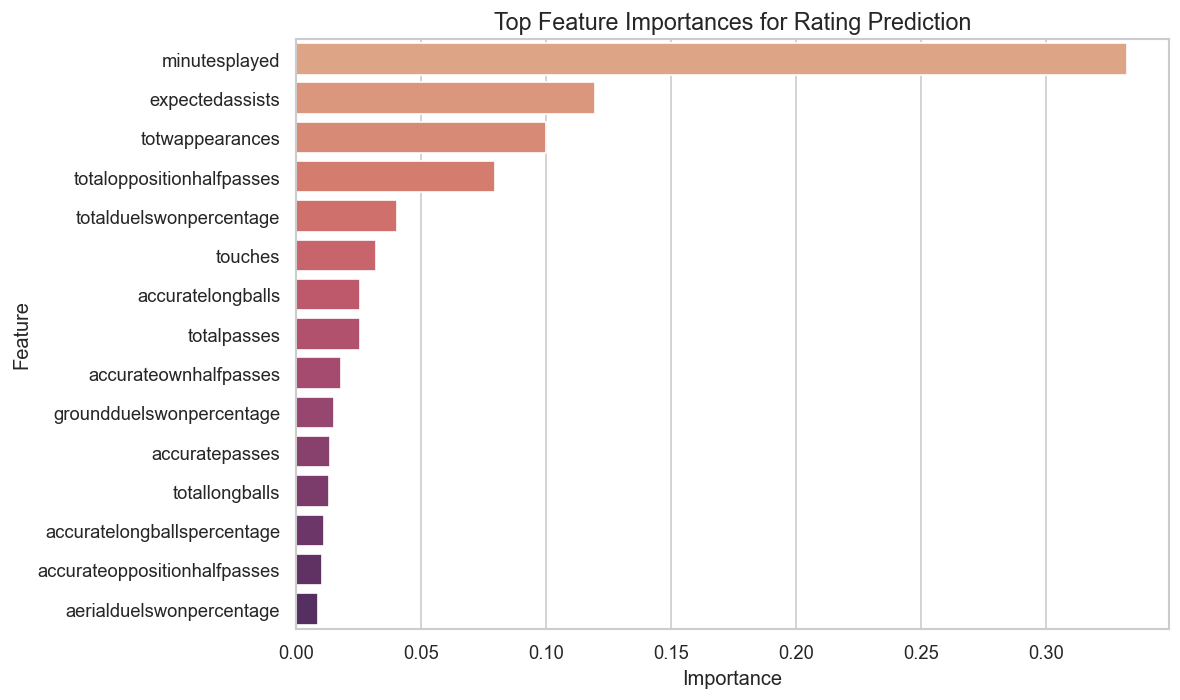

In [11]:
# ==============================
# 6C. Regression: Predict Player Rating
# ==============================

if rating_col is None:
    raise ValueError('Rating column could not be identified. Regression task requires a rating target column.')

regression_df = analysis_df.copy()
regression_df = regression_df[regression_df[rating_col].notna()].copy()

regression_features = get_numeric_columns(regression_df)
regression_features = [
    col for col in regression_features
    if col not in [rating_col, 'cluster']
]

X_reg = regression_df[regression_features].copy()
y_reg = pd.to_numeric(regression_df[rating_col], errors='coerce')

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

reg_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE
    ))
])

reg_pipeline.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_pipeline.predict(X_test_reg)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f'RMSE: {rmse:.4f}')
print(f'R^2 Score: {r2:.4f}')

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.75)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.title('Actual vs Predicted Player Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.tight_layout()
plt.show()

reg_model = reg_pipeline.named_steps['model']
feature_importance_reg = (
    pd.Series(reg_model.feature_importances_, index=regression_features)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_reg.values, y=feature_importance_reg.index, palette='flare')
plt.title('Top Feature Importances for Rating Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. Additional Visualizations

This section adds communication-friendly charts for football insights:
- Top players by contribution
- Top players by defensive score
- Radar chart comparing two players across selected attributes

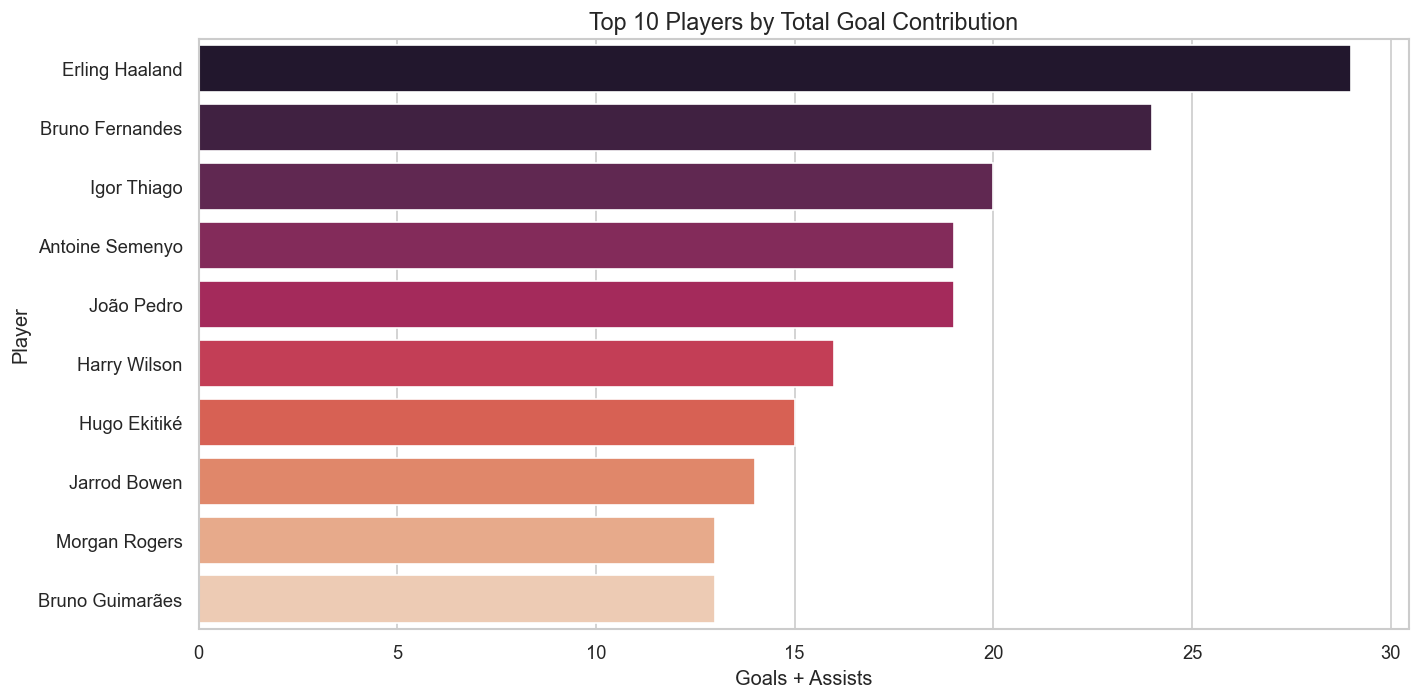

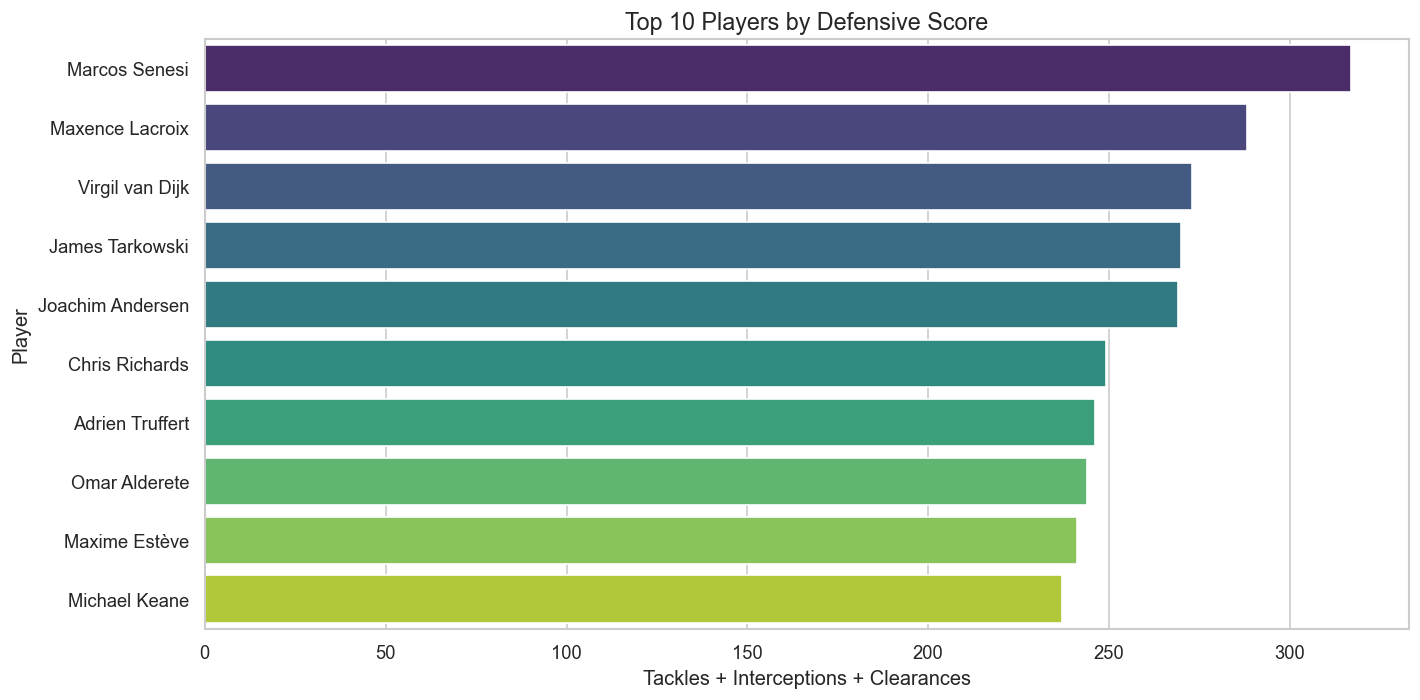

In [12]:
# ==============================
# 7A. Top Players by Key Metrics
# ==============================

if player_col is not None:
    top_contributors = analysis_df[[player_col, 'total_contribution']].dropna().sort_values('total_contribution', ascending=False).head(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_contributors, x='total_contribution', y=player_col, palette='rocket')
    plt.title('Top 10 Players by Total Goal Contribution')
    plt.xlabel('Goals + Assists')
    plt.ylabel('Player')
    plt.tight_layout()
    plt.show()

    top_defenders = analysis_df[[player_col, 'defensive_score']].dropna().sort_values('defensive_score', ascending=False).head(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_defenders, x='defensive_score', y=player_col, palette='viridis')
    plt.title('Top 10 Players by Defensive Score')
    plt.xlabel('Tackles + Interceptions + Clearances')
    plt.ylabel('Player')
    plt.tight_layout()
    plt.show()

Radar chart defaults: Erling Haaland vs Bruno Fernandes


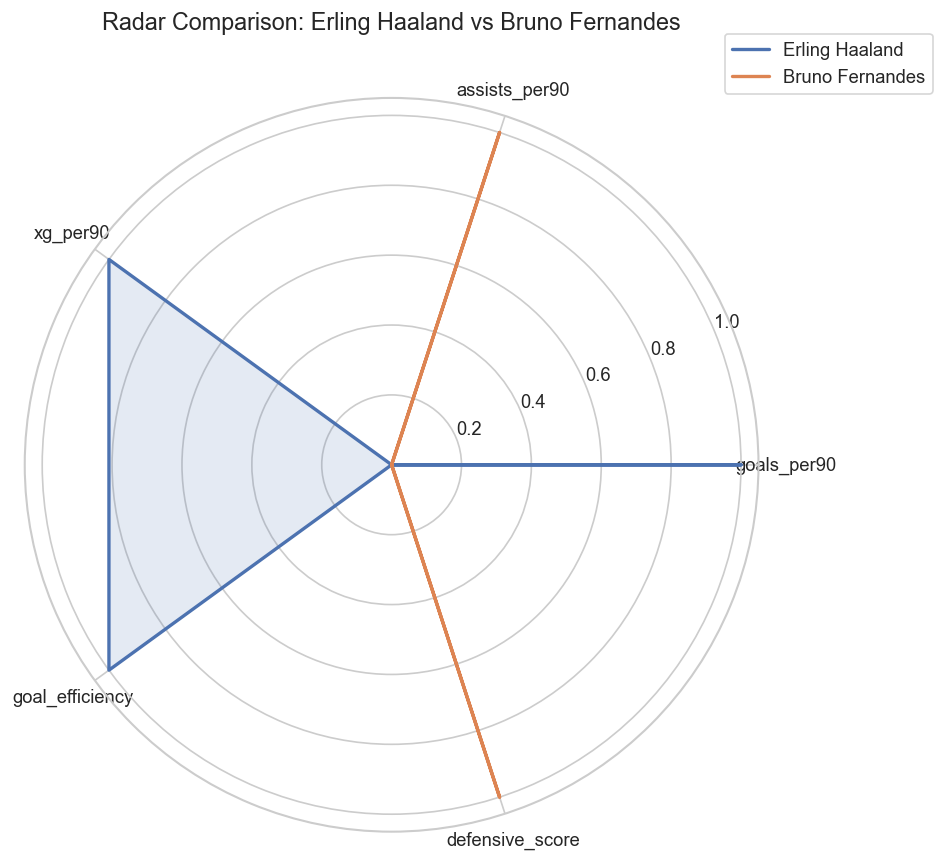

In [13]:
# ==============================
# 7B. Radar Chart for Player Comparison
# ==============================

def plot_radar_comparison(dataframe, player_name_col, player_a, player_b, metrics):
    """Compare two players on selected metrics using a radar chart."""
    subset = dataframe[dataframe[player_name_col].isin([player_a, player_b])].copy()
    if subset.shape[0] < 2:
        raise ValueError('Could not find both players for radar comparison.')

    radar_df = subset[[player_name_col] + metrics].set_index(player_name_col)
    radar_df = radar_df.apply(pd.to_numeric, errors='coerce').fillna(0)

    scaled = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)

    categories = metrics
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for player in scaled.index:
        values = scaled.loc[player].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=player)
        ax.fill(angles, values, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_title(f'Radar Comparison: {player_a} vs {player_b}', y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.10))
    plt.tight_layout()
    plt.show()


if player_col is not None:
    radar_metrics = [
        col for col in [
            'goals_per90',
            'assists_per90',
            'xg_per90',
            'goal_efficiency',
            'defensive_score'
        ] if col in analysis_df.columns
    ]

    available_players = (
        analysis_df[[player_col, 'total_contribution']]
        .dropna()
        .sort_values('total_contribution', ascending=False)[player_col]
        .tolist()
    )

    if len(available_players) >= 2 and len(radar_metrics) >= 3:
        player_a = available_players[0]
        player_b = available_players[1]
        print(f'Radar chart defaults: {player_a} vs {player_b}')
        plot_radar_comparison(analysis_df, player_col, player_a, player_b, radar_metrics)
    else:
        print('Not enough players or metrics available to build the radar chart.')

## 8. Insights & Conclusions

This final section is intended to summarize the most important football and modeling insights once the notebook has been run.

### Recommended themes to discuss
- Which players lead the league in pure output, efficiency, and defensive activity?
- Do expected metrics align closely with actual outcomes?
- Which positions are easiest or hardest to classify from statistics?
- Do clusters correspond to meaningful football roles?
- Which variables matter most for predicting player rating?

### Dataset limitations to acknowledge
- Ratings may be subjective or provider-specific
- Per-90 metrics can exaggerate small-sample players with low minutes
- Goalkeeper and outfield metrics are structurally different
- Some missing values may reflect role-specific non-participation rather than poor data quality
- Team tactics and player roles are not fully captured by box-score style statistics alone

In [14]:
# ==============================
# 8. Automated Insight Summaries
# ==============================

def top_player_table(metric, top_n=5):
    if player_col is None or metric not in analysis_df.columns:
        return pd.DataFrame()
    return (
        analysis_df[[player_col, metric]]
        .dropna()
        .sort_values(metric, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


print('Top players by total contribution:')
display(top_player_table('total_contribution'))

print('Top players by goal efficiency:')
display(top_player_table('goal_efficiency'))

print('Top players by defensive score:')
display(top_player_table('defensive_score'))

if position_col is not None and 'cluster' in analysis_df.columns:
    print('Cluster counts by position:')
    display(pd.crosstab(analysis_df['cluster'], analysis_df[position_col]))

if rating_col is not None:
    print('Top players by rating:')
    display(top_player_table(rating_col))

Top players by total contribution:


,player_name,total_contribution
0,Erling Haaland,29
1,Bruno Fernandes,24
2,Igor Thiago,20
3,Antoine Semenyo,19
4,João Pedro,19


Top players by goal efficiency:


,player_name,goal_efficiency
0,Harrison Reed,7.943
1,Tom Edozie,6.068
2,Tyler Adams,3.760
3,Rúben Dias,3.544
4,Jarrad Branthwaite,3.470


Top players by defensive score:


,player_name,defensive_score
0,Marcos Senesi,317
1,Maxence Lacroix,288
2,Virgil van Dijk,273
3,James Tarkowski,270
4,Joachim Andersen,269


Cluster counts by position:


position,D,F,G,M
cluster,,,,
0,91,63,35,119
1,81,0,0,46
2,0,34,0,47
3,0,0,0,1


Top players by rating:


,player_name,rating
0,Tom Edozie,7.600
1,Bruno Fernandes,7.550
2,Declan Rice,7.490
3,Bruno Guimarães,7.487
4,Rodri,7.453
